In [4]:
pip install pyarrow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.5/29.5 MB 7.4 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [30]:
# read parquet file
import pandas as pd
import pyarrow.parquet as pq

parquet_file_path = '/Users/zahrataghizadeh/Desktop/ADA/YouNiverse/filtered_sport_category_without_description_column_metadata.parquet'
pq_metadata = pq.ParquetFile(parquet_file_path)


In [32]:
# convert parquet file to pandas dataframe
table = pq_metadata.read()
df = table.to_pandas()


In [29]:
print(df.head())
#get the columns of the dataframe

print(df.columns)

        categories                channel_id                  crawl_date  \
399294      Sports  UCnrO0wqhKpMYUt_wSeaIasw  2019-11-02 14:37:27.449492   
1656682     Sports  UCWw6scNyopJ0yjMu1SyOEyw  2019-11-01 08:13:39.410696   
1926827     Sports  UCTl3QQTvqHFjurroKxexy2Q  2019-11-04 00:48:20.739148   
2086166     Sports  UCRijo3ddMTht_IHyNSNXpNQ  2019-10-29 17:12:21.529595   
3370238     Sports  UCBF8RBoAXR_m0yWfjuO1lvQ  2019-11-15 12:09:17.711127   

         dislike_count   display_id  duration  like_count  \
399294         23553.0  3bwv3L8uE3s       561    198162.0   
1656682         8219.0  YRAIK1DclGo       196     40091.0   
1926827         8448.0  CwzjlmBLfrQ       337    468226.0   
2086166        21615.0  i25i6vyjIpg      1169    510875.0   
3370238        17844.0  svfI-bTdMcI       203    493062.0   

                                                      tags  \
399294   bratayley,olympics,shout-out,shout,out,video,g...   
1656682  sports,soccer,football,funny,lol,lmao,aweso

In [10]:
pip install wordcloud


[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


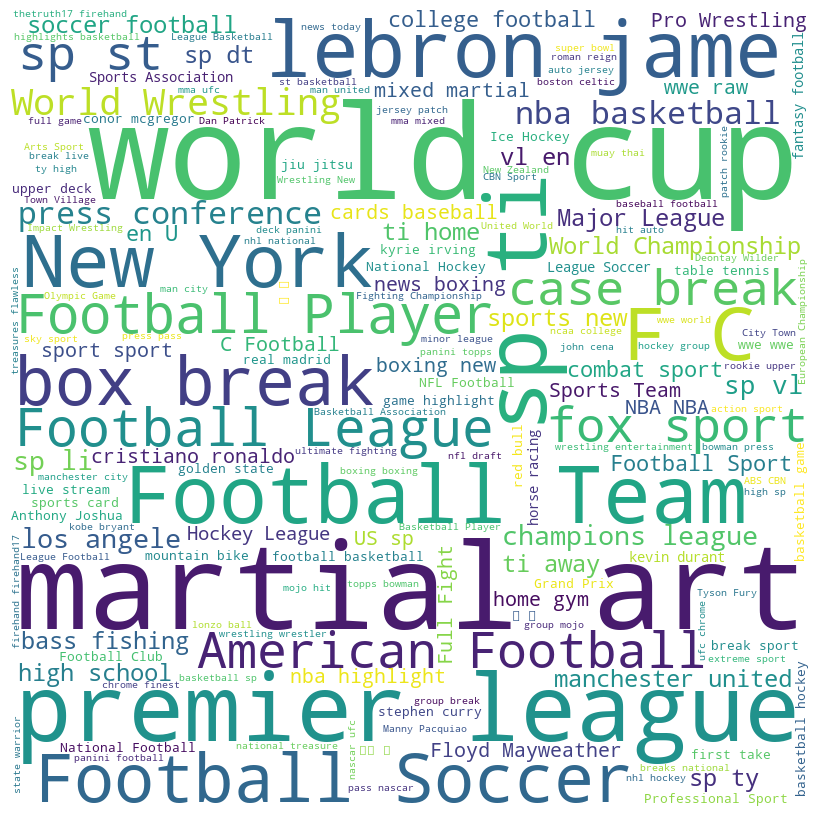

In [11]:
# make the word cloud for the tags
from wordcloud import WordCloud

import matplotlib.pyplot as plt

tags = df['tags'].values
tags = ' '.join(tags)
wordcloud = WordCloud(width = 800, height = 800,
                background_color ='white',
                stopwords = None,
                min_font_size = 10).generate(tags)
plt.figure(figsize = (8, 8), facecolor = None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad = 0)
plt.show()



In [21]:
# get those data with the tags in the list below

tags_list = ['Olympics', 'olympics', 'Summer Olympics',  ]
df = df[df['tags'].str.contains('|'.join(tags_list))]
print(df.head())


     categories                channel_id                  crawl_date  \
818      Sports  UCzTfnC661R3LXu_mS9aRFKA  2019-11-04 11:07:21.100437   
1045     Sports  UCzSq7O3MmG-EF0Gq68uSjPw  2019-11-23 14:42:56.211570   
1046     Sports  UCzSq7O3MmG-EF0Gq68uSjPw  2019-11-23 14:43:07.484920   
1047     Sports  UCzSq7O3MmG-EF0Gq68uSjPw  2019-11-23 14:43:13.676141   
1048     Sports  UCzSq7O3MmG-EF0Gq68uSjPw  2019-11-23 14:43:15.000911   

      dislike_count   display_id  duration  like_count  \
818             8.0  TOi8me9ijvc        55       171.0   
1045            0.0  VoicqeYw_KY       161         5.0   
1046            1.0  -JPehFNMNio       151        11.0   
1047            0.0  3-PlTZEXnPg       179         4.0   
1048            1.0  M8eRQ5hiRJM       123         3.0   

                                                   tags  \
818   Matt Watson,New Zealand,Fishing,Fish,Ultimate,...   
1045  Paralympics,Iran,London,Press TV,Nargess Mobal...   
1046  Roshan Muhammed Salih,Iran,Pr

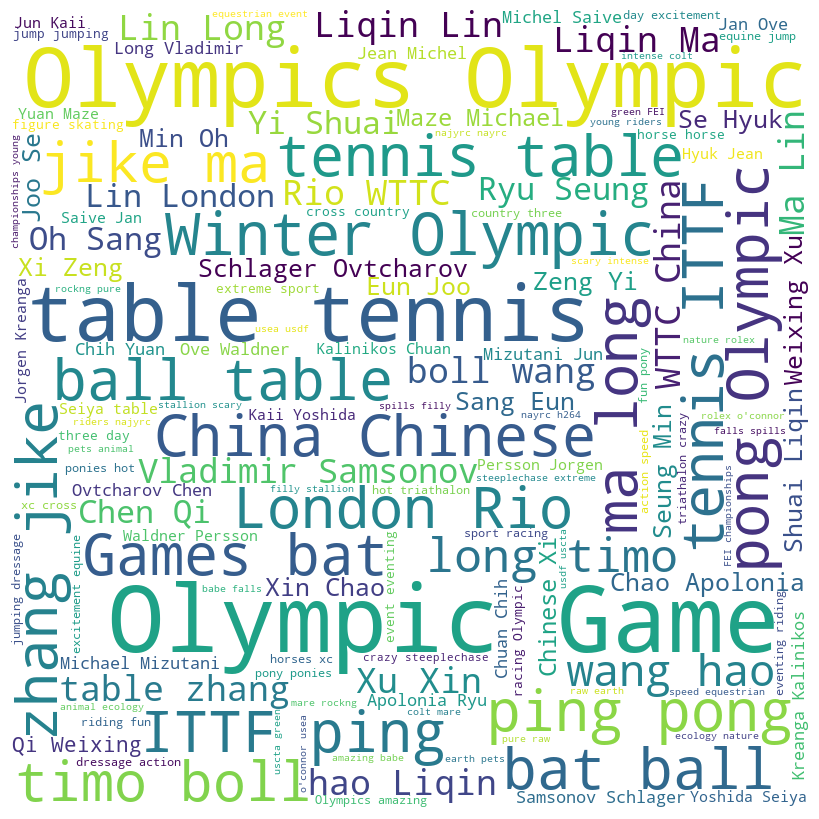

In [13]:
#make the word cloud for the filtered tags
tags = df['tags'].values
tags = ' '.join(tags)
wordcloud = WordCloud(width = 800, height = 800,
                background_color ='white',
                stopwords = None,
                min_font_size = 10).generate(tags)
plt.figure(figsize = (8, 8), facecolor = None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad = 0)
plt.show()


In [24]:
# get the most viewed videos
df = df.sort_values(by='view_count', ascending=False)
print(df.head())


        categories                channel_id                  crawl_date  \
399294      Sports  UCnrO0wqhKpMYUt_wSeaIasw  2019-11-02 14:37:27.449492   
1656682     Sports  UCWw6scNyopJ0yjMu1SyOEyw  2019-11-01 08:13:39.410696   
1926827     Sports  UCTl3QQTvqHFjurroKxexy2Q  2019-11-04 00:48:20.739148   
2086166     Sports  UCRijo3ddMTht_IHyNSNXpNQ  2019-10-29 17:12:21.529595   
3370238     Sports  UCBF8RBoAXR_m0yWfjuO1lvQ  2019-11-15 12:09:17.711127   

         dislike_count   display_id  duration  like_count  \
399294         23553.0  3bwv3L8uE3s       561    198162.0   
1656682         8219.0  YRAIK1DclGo       196     40091.0   
1926827         8448.0  CwzjlmBLfrQ       337    468226.0   
2086166        21615.0  i25i6vyjIpg      1169    510875.0   
3370238        17844.0  svfI-bTdMcI       203    493062.0   

                                                      tags  \
399294   bratayley,olympics,shout-out,shout,out,video,g...   
1656682  sports,soccer,football,funny,lol,lmao,aweso

In [41]:
# Convert 'upload_date' to datetime
df['upload_date'] = pd.to_datetime(df['upload_date'], errors='coerce')

# Check for any conversion issues
print(df['upload_date'].isnull().sum(), "rows have invalid 'upload_date'")

# Create 'year_month' as a Period (e.g., '2020-08')
df['year_month'] = df['upload_date'].dt.to_period('M')

# Verify the creation
print(df[['upload_date', 'year_month']].head())


0 rows have invalid 'upload_date'
  upload_date year_month
0  2019-10-01    2019-10
1  2019-10-01    2019-10
2  2019-09-28    2019-09
3  2019-09-21    2019-09
4  2019-09-14    2019-09


In [42]:
# Define a list of Olympics-related keywords
olympics_keywords = [
    'olympic', 'olympics', 'olympiad', 'beijing 2008', 'london 2012',
    'rio 2016', 'pyeongchang 2018', 'sochi 2014', 'tokyo 2020', 'olympic games',
    'winter olympics', 'summer olympics'
]

# Convert to lowercase for case-insensitive matching
df['title_lower'] = df['title'].str.lower()
df['tags_lower'] = df['tags'].str.lower()

# Function to check if any keyword is in the text
def contains_olympics(text):
    if pd.isnull(text):
        return False
    for keyword in olympics_keywords:
        if keyword in text:
            return True
    return False

# Apply function to title and tags
df['is_olympics'] = df['title_lower'].apply(contains_olympics) | df['tags_lower'].apply(contains_olympics)

# Filter Olympics-related videos
olympics_videos = df[df['is_olympics']]


In [43]:
print(olympics_videos['title'].head(20))


497                 Marcelo Garcia and Jimmy Pedro Rolling
526      UFC Fighter Sara McMann Training at Marcelo Ga...
818                                       MAKO SHARK JUMPS
1045              Iran's Paralympic team arrives in London
1046             McDonalds dominates London's Olympic Park
1047                      Empty seats blight Olympic Games
1048                         Iran aims for Olympic success
1049     Protestors March Against "Corporate and Milita...
1050        Will Muslim athletes fast during the Olympics?
1265                 Judo match Sonnemans -  Olympics 1996
5241     Rewind: Devon Allen junior season (Brophy Prep...
6839     Junior & Megacrew Division Qualifiers | Day 5 ...
7723     FUSION - BEAUTIFUL SPANISH MARE SIRED BY OLYMP...
7820        Vancouver 2010 Olympic Torch Relay New Glasgow
9989           Wod Demo - Jerk Complex (Paradiso CrossFit)
10008            Wod Demo - Max Snatch (Paradiso CrossFit)
10020                Venice Barbell Club - Snatch Warmup

In [44]:
df['upload_date'] = pd.to_datetime(df['upload_date'])
df['year'] = df['upload_date'].dt.year
df['month'] = df['upload_date'].dt.month
df['year_month'] = df['upload_date'].dt.to_period('M')
print("\nColumns in olympics_videos:")
print(olympics_videos.columns)



Columns in olympics_videos:
Index(['categories', 'channel_id', 'crawl_date', 'dislike_count', 'display_id',
       'duration', 'like_count', 'tags', 'title', 'upload_date', 'view_count',
       'title_lower', 'tags_lower', 'is_olympics', 'year', 'month',
       'year_month'],
      dtype='object')


## Trend Analysis Over Time


In [46]:

total_videos_monthly = df.groupby('year_month').size().reset_index(name='total_videos')
olympics_videos_monthly = olympics_videos.groupby('year_month').size().reset_index(name='olympics_videos')
merged_counts = pd.merge(total_videos_monthly, olympics_videos_monthly, on='year_month', how='left')
merged_counts['olympics_videos'].fillna(0, inplace=True)
merged_counts['proportion'] = merged_counts['olympics_videos'] / merged_counts['total_videos']
# Display the merged_counts DataFrame
print(merged_counts.head())

  year_month  total_videos  olympics_videos  proportion
0    2005-05             1              0.0         0.0
1    2005-10             1              0.0         0.0
2    2005-11             1              0.0         0.0
3    2006-01             3              0.0         0.0
4    2006-02            10              0.0         0.0


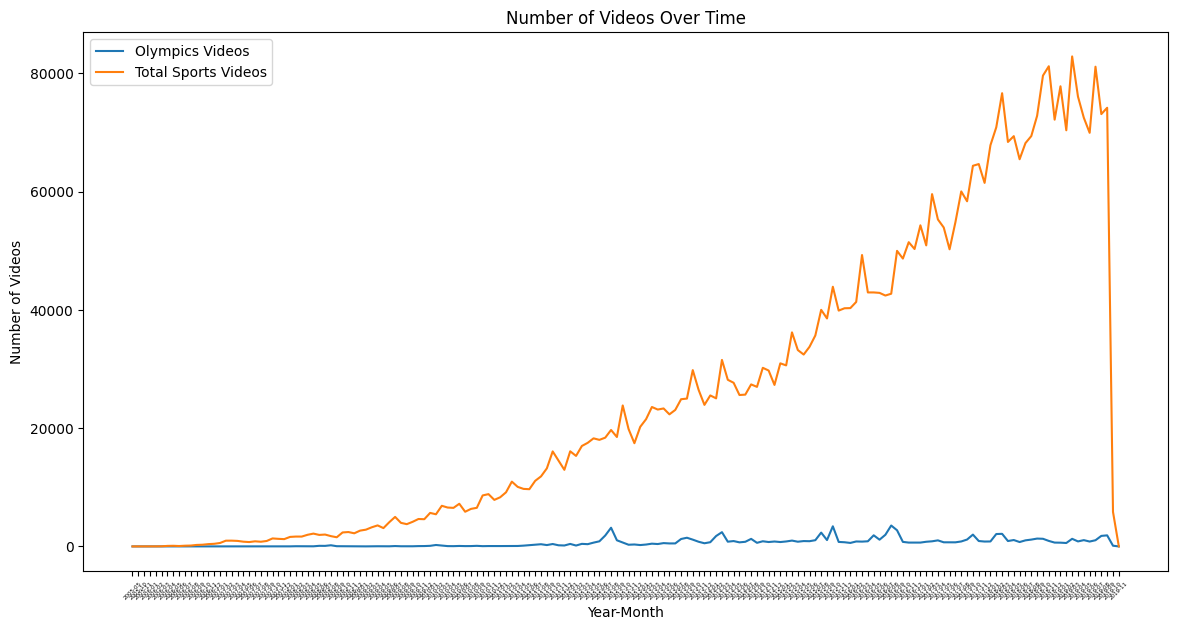

In [53]:
plt.figure(figsize=(14,7))
plt.plot(merged_counts['year_month'].astype(str), merged_counts['olympics_videos'], label='Olympics Videos')
plt.plot(merged_counts['year_month'].astype(str), merged_counts['total_videos'], label='Total Sports Videos')
plt.xlabel('Year-Month')
plt.ylabel('Number of Videos')
plt.title('Number of Videos Over Time')
plt.legend()
plt.xticks(rotation=45)
# make the x-axis labels smaller
plt.xticks(fontsize=4)
plt.show()


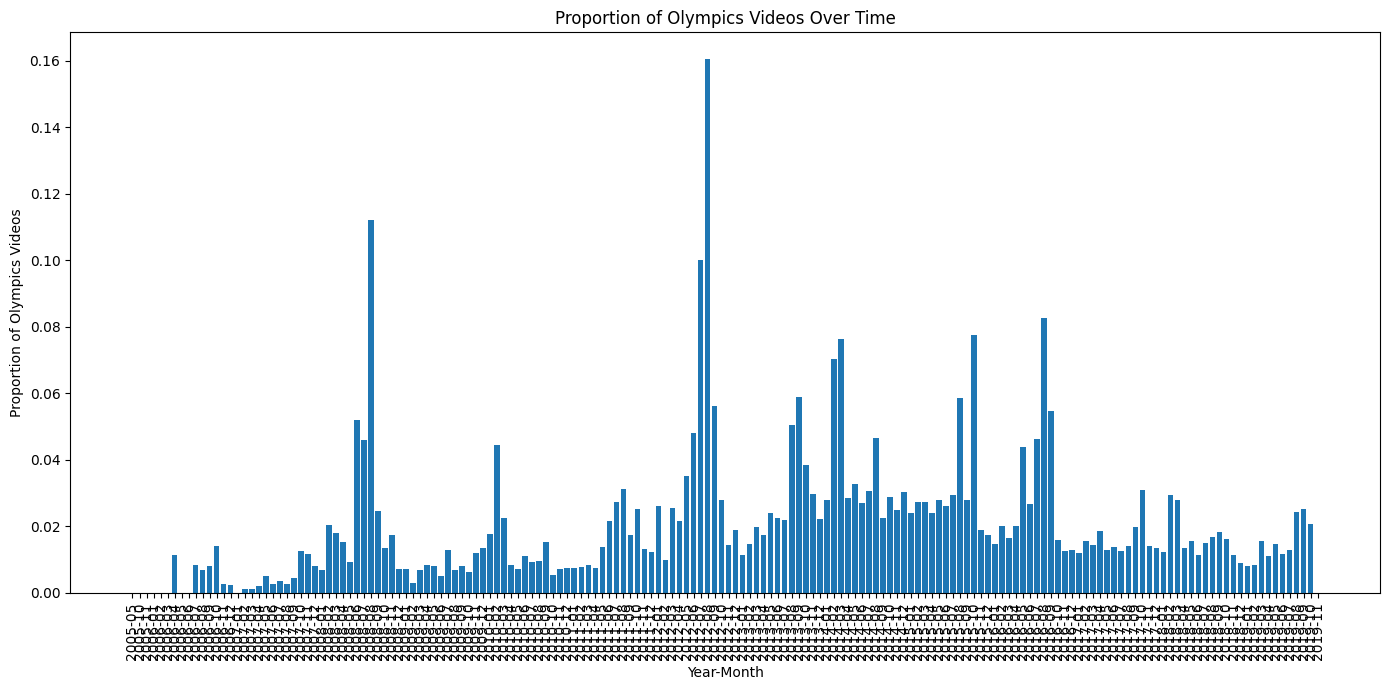

In [54]:
plt.figure(figsize=(14,7))
plt.bar(merged_counts['year_month'].astype(str), merged_counts['proportion'])
plt.xlabel('Year-Month')
plt.ylabel('Proportion of Olympics Videos')
plt.title('Proportion of Olympics Videos Over Time')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


## Engagement Metrics

/var/folders/77/5ydnmbx94b19w3vljgff8zlm0000gn/T/ipykernel_84638/4223673890.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  olympics_videos[col] = pd.to_numeric(olympics_videos[col], errors='coerce')


               All Sports Videos  Olympics Videos
view_count          60170.382692     52638.153277
like_count            588.257022       390.517868
dislike_count          30.905055        19.844107


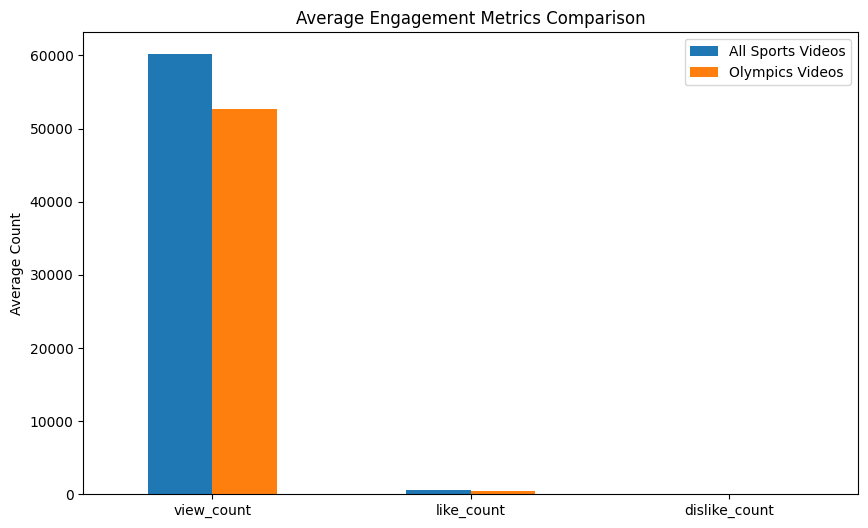

In [61]:
# Ensure numeric types
for col in ['view_count', 'like_count', 'dislike_count']:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    olympics_videos[col] = pd.to_numeric(olympics_videos[col], errors='coerce')
avg_metrics_all = df[['view_count', 'like_count', 'dislike_count']].mean()
avg_metrics_olympics = olympics_videos[['view_count', 'like_count', 'dislike_count']].mean()
engagement_comparison = pd.DataFrame({
    'All Sports Videos': avg_metrics_all,
    'Olympics Videos': avg_metrics_olympics
})
print(engagement_comparison)

engagement_comparison.plot(kind='bar', figsize=(10,6))
plt.title('Average Engagement Metrics Comparison')
plt.ylabel('Average Count')
plt.xticks(rotation=0)
plt.show()


In [ ]:
olympics_videos['likes_per_view'] = olympics_videos['likes'] / olympics_videos['views']
df['likes_per_view'] = df['likes'] / df['views']

avg_likes_per_view_olympics = olympics_videos['likes_per_view'].mean()
avg_likes_per_view_all = df['likes_per_view'].mean()


## Impact of Specific Olympic Events

Beijing 2008 (2008-08-08 - 2008-08-24):
Total Olympics Videos Uploaded: 305
Average Views per Video: 25160.668852459017
----------------------------------------
Vancouver 2010 (2010-02-12 - 2010-02-28):
Total Olympics Videos Uploaded: 477
Average Views per Video: 99163.21383647798
----------------------------------------
London 2012 (2012-07-27 - 2012-08-12):
Total Olympics Videos Uploaded: 5448
Average Views per Video: 200690.90675477238
----------------------------------------
Sochi 2014 (2014-02-07 - 2014-02-23):
Total Olympics Videos Uploaded: 4557
Average Views per Video: 48906.11806012728
----------------------------------------
Rio 2016 (2016-08-05 - 2016-08-21):
Total Olympics Videos Uploaded: 7537
Average Views per Video: 81103.67148732918
----------------------------------------
PyeongChang 2018 (2018-02-09 - 2018-02-25):
Total Olympics Videos Uploaded: 4771
Average Views per Video: 45739.867113812616
----------------------------------------


/var/folders/77/5ydnmbx94b19w3vljgff8zlm0000gn/T/ipykernel_84638/808288430.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  period_data['date'] = period_data['upload_date'].dt.date


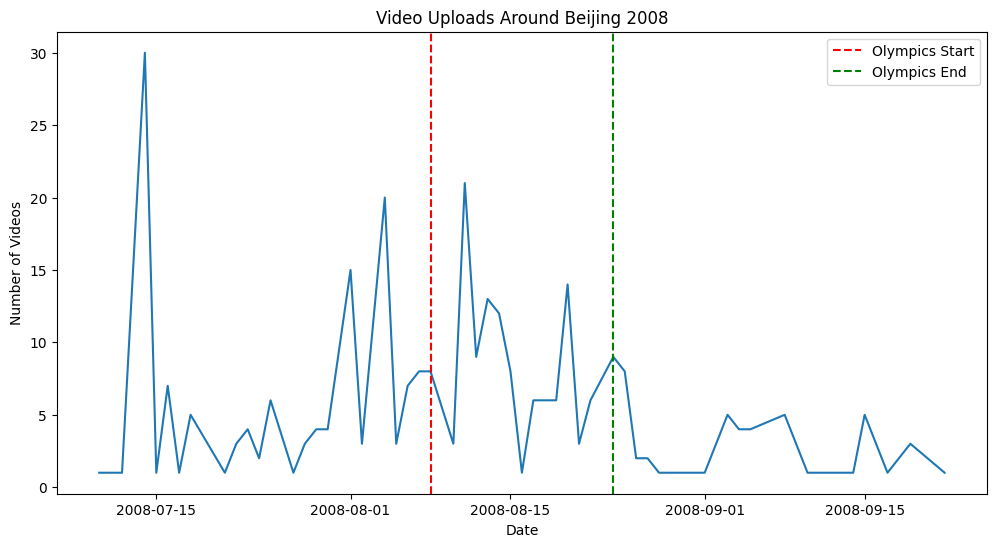

/var/folders/77/5ydnmbx94b19w3vljgff8zlm0000gn/T/ipykernel_84638/808288430.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  period_data['date'] = period_data['upload_date'].dt.date


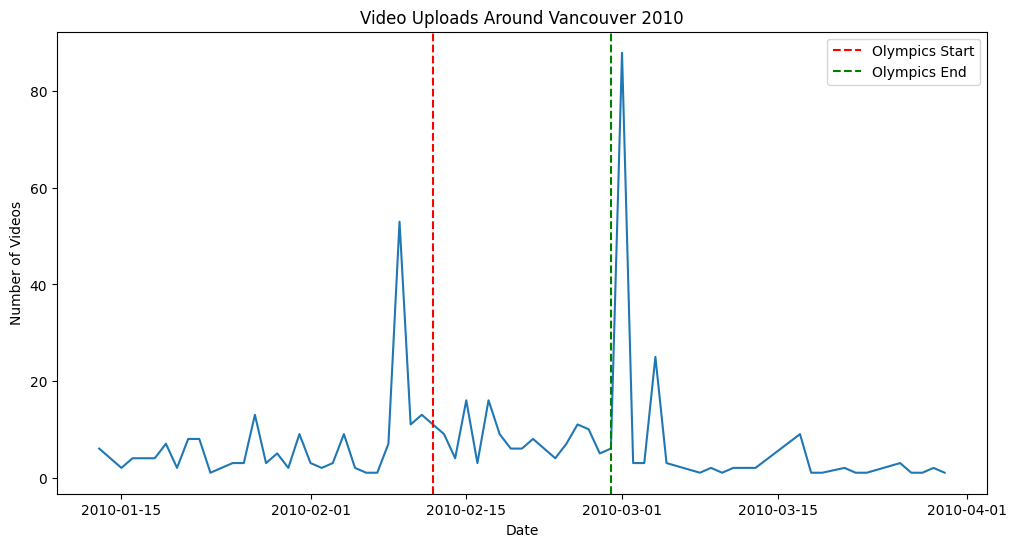

/var/folders/77/5ydnmbx94b19w3vljgff8zlm0000gn/T/ipykernel_84638/808288430.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  period_data['date'] = period_data['upload_date'].dt.date


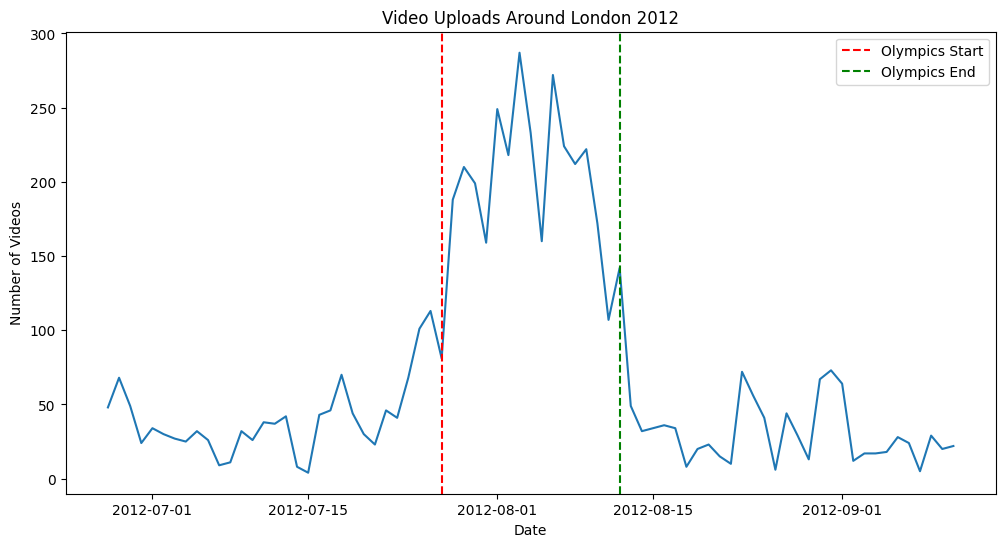

/var/folders/77/5ydnmbx94b19w3vljgff8zlm0000gn/T/ipykernel_84638/808288430.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  period_data['date'] = period_data['upload_date'].dt.date


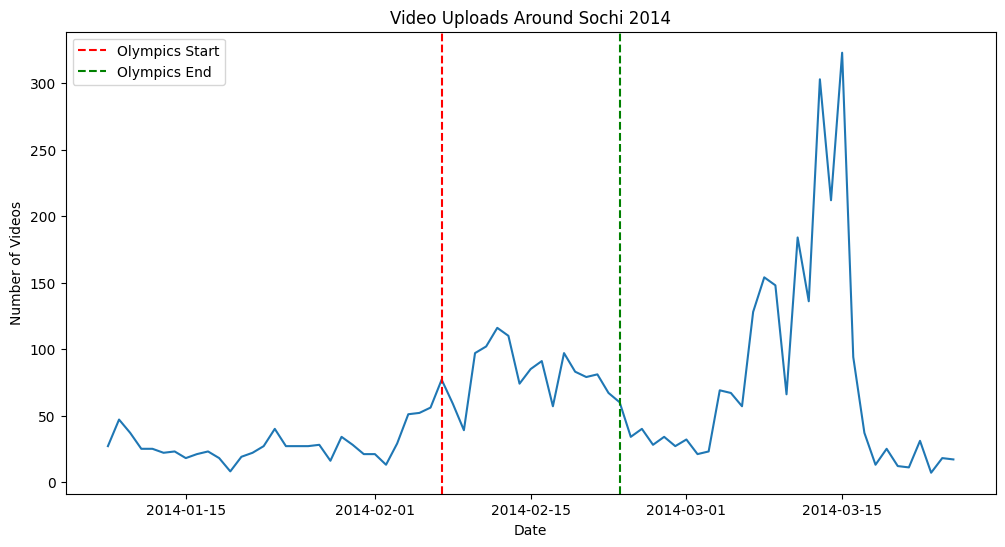

/var/folders/77/5ydnmbx94b19w3vljgff8zlm0000gn/T/ipykernel_84638/808288430.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  period_data['date'] = period_data['upload_date'].dt.date


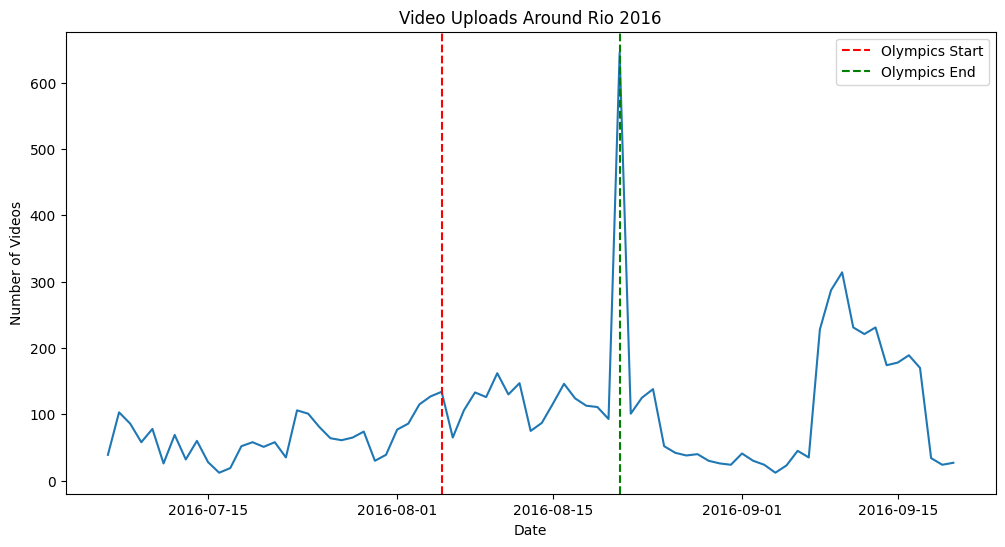

/var/folders/77/5ydnmbx94b19w3vljgff8zlm0000gn/T/ipykernel_84638/808288430.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  period_data['date'] = period_data['upload_date'].dt.date


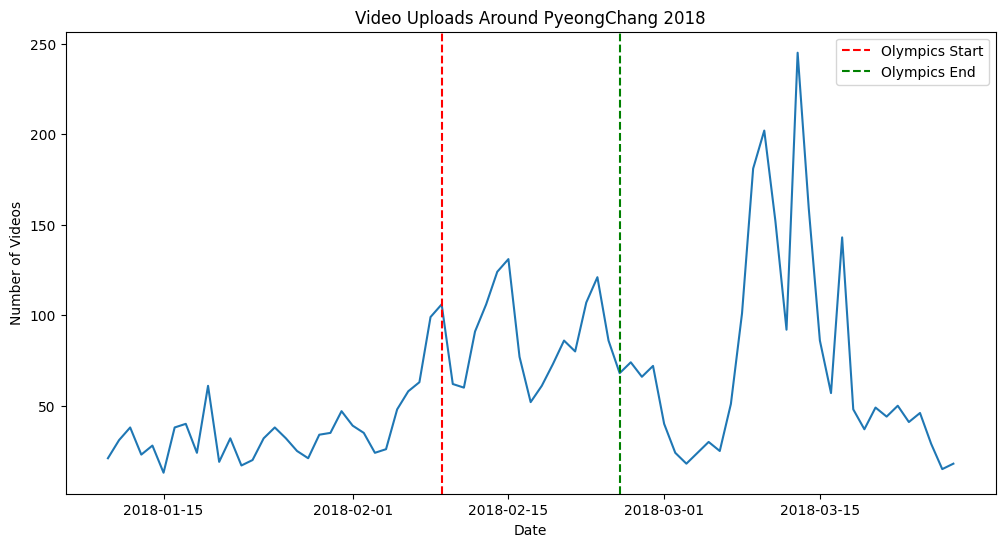

In [87]:
from datetime import datetime, timedelta

olympic_periods = [
    ('Beijing 2008', datetime(2008, 8, 8), datetime(2008, 8, 24)),
    ('Vancouver 2010', datetime(2010, 2, 12), datetime(2010, 2, 28)),
    ('London 2012', datetime(2012, 7, 27), datetime(2012, 8, 12)),
    ('Sochi 2014', datetime(2014, 2, 7), datetime(2014, 2, 23)),
    ('Rio 2016', datetime(2016, 8, 5), datetime(2016, 8, 21)),
    ('PyeongChang 2018', datetime(2018, 2, 9), datetime(2018, 2, 25))
]

for name, start_date, end_date in olympic_periods:
    # One month before and after
    period_start = start_date - timedelta(days=30)
    period_end = end_date + timedelta(days=30)

    period_videos = olympics_videos[(olympics_videos['upload_date'] >= period_start) & (olympics_videos['upload_date'] <= period_end)]

    total_videos = len(period_videos)
    avg_views = period_videos['view_count'].mean()

    print(f"{name} ({start_date.date()} - {end_date.date()}):")
    print(f"Total Olympics Videos Uploaded: {total_videos}")
    print(f"Average Views per Video: {avg_views}")
    print("-" * 40)
for name, start_date, end_date in olympic_periods:
    period_start = start_date - timedelta(days=30)
    period_end = end_date + timedelta(days=30)

    mask = (olympics_videos['upload_date'] >= period_start) & (olympics_videos['upload_date'] <= period_end)
    period_data = olympics_videos.loc[mask]

    period_data['date'] = period_data['upload_date'].dt.date
    daily_counts = period_data.groupby('date').size().reset_index(name='video_count')

    plt.figure(figsize=(12,6))
    plt.plot(daily_counts['date'], daily_counts['video_count'])
    plt.axvline(start_date, color='r', linestyle='--', label='Olympics Start')
    plt.axvline(end_date, color='g', linestyle='--', label='Olympics End')
    plt.title(f'Video Uploads Around {name}')
    plt.xlabel('Date')
    plt.ylabel('Number of Videos')
    plt.legend()
    plt.show()


## Content Analysis (Titles and Tags)

## Sentiment Analysis of Titles

In [ ]:
# Install TextBlob if not already installed
!pip install textblob




In [ ]:
from textblob import TextBlob
def get_sentiment(text):
    if pd.isnull(text):
        return 0
    analysis = TextBlob(text)
    return analysis.sentiment.polarity

olympics_videos['sentiment'] = olympics_videos['title'].apply(get_sentiment)
sentiment_over_time = olympics_videos.groupby('year_month')['sentiment'].mean().reset_index()

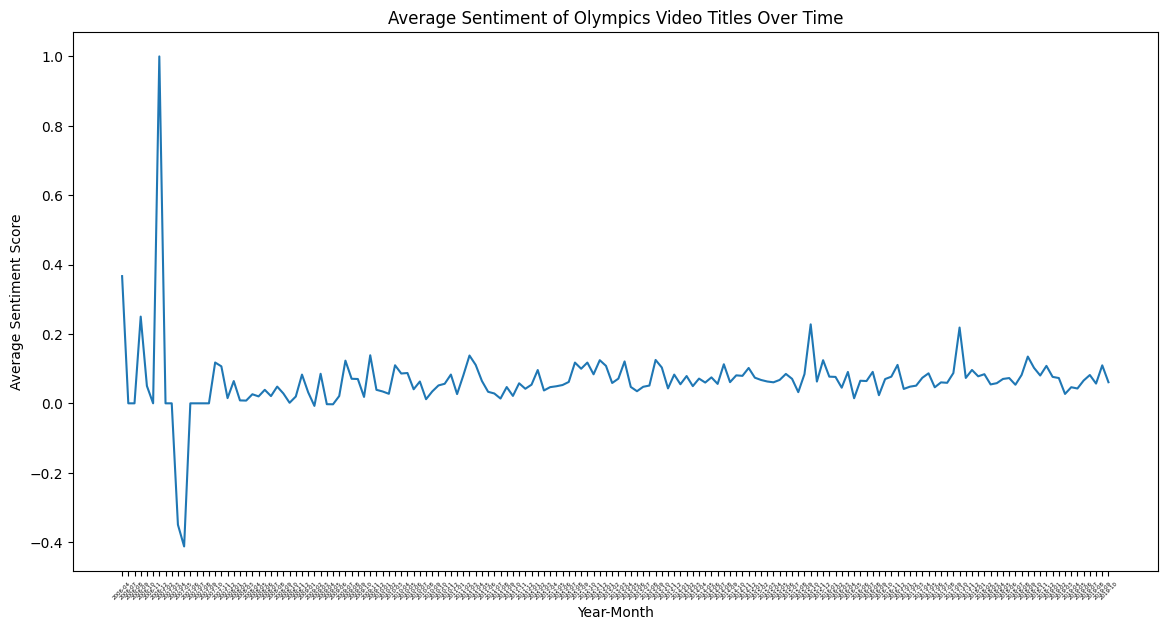

In [74]:
plt.figure(figsize=(14,7))
plt.plot(sentiment_over_time['year_month'].astype(str), sentiment_over_time['sentiment'])
plt.xlabel('Year-Month')
plt.ylabel('Average Sentiment Score')
plt.title('Average Sentiment of Olympics Video Titles Over Time')
plt.xticks(size=4, rotation=45)
plt.show()

## Channel Analysis

In [75]:
top_channels = olympics_videos['channel_id'].value_counts().head(10).index
top_channels_videos = olympics_videos[olympics_videos['channel_id'].isin(top_channels)]

# Get channel names if available
top_channels_engagement = top_channels_videos.groupby('channel_id')[['view_count', 'like_count', 'dislike_count']].mean()
print(top_channels_engagement)


                             view_count   like_count  dislike_count
channel_id                                                         
UC8XRC858pOERvclUDb_d7rg    4392.858531    25.573434       1.019978
UC9ckyA_A3MfXUa0ttxMoIZw   29629.944263   186.886484       8.607595
UCAM9Pvp3HzKvIAbAXHxidow   12182.636685    50.752253       2.707722
UCPGpDwKpKj9vcoFAOxSbr7A   28365.133136   135.878107       4.471598
UCTl3QQTvqHFjurroKxexy2Q  247753.954119  1283.219088      64.199003
UCUXhCQ-mQCWq1F-3Ys-6aLg    1963.947944     6.967884       1.344803
UCb467UvO4jRgKxWX1oqtkzA   15679.789474   119.922876       5.615425
UCbv3gsBXzIwotCt2JGySfJA    4501.083616    40.307124       3.371782
UChh-akEbUM8_6ghGVnJd6cQ   46529.607483   105.024211       9.297872
UCi8n36NkW2uCQSFZNiYtuMQ   11379.047416    60.999389       3.549969


In [77]:
# Already have avg_metrics_olympics and avg_metrics_all from earlier steps

# Calculate metrics for non-Olympics sports videos
non_olympics_videos = df[~df['is_olympics']]

avg_metrics_non_olympics = non_olympics_videos[['view_count', 'like_count', 'dislike_count']].mean()
comparison_df = pd.DataFrame({
    'Olympics Videos': avg_metrics_olympics,
    'Non-Olympics Sports Videos': avg_metrics_non_olympics
})
print(comparison_df)
from scipy.stats import ttest_ind

metrics = ['view_count', 'like_count', 'dislike_count']
for metric in metrics:
    t_stat, p_val = ttest_ind(olympics_videos[metric].dropna(), non_olympics_videos[metric].dropna(), equal_var=False)
    print(f"{metric}: t-statistic={t_stat}, p-value={p_val}")


               Olympics Videos  Non-Olympics Sports Videos
view_count        52638.153277                60350.246703
like_count          390.517868                  592.983141
dislike_count        19.844107                   31.169421
view_count: t-statistic=-4.565305537226484, p-value=4.992973581411629e-06
like_count: t-statistic=-13.527897238936745, p-value=1.1525872827850525e-41
dislike_count: t-statistic=-7.0005227384433475, p-value=2.564966321273634e-12


/var/folders/77/5ydnmbx94b19w3vljgff8zlm0000gn/T/ipykernel_84638/333966109.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  olympics_videos['likes_per_view'] = olympics_videos['like_count'] / olympics_videos['view_count']
/var/folders/77/5ydnmbx94b19w3vljgff8zlm0000gn/T/ipykernel_84638/333966109.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  olympics_videos['dislikes_per_view'] = olympics_videos['dislike_count'] / olympics_videos['view_count']
/var/folders/77/5ydnmbx94b19w3vljgff8zlm0000gn/T/ipykern

      likes_per_view  dislikes_per_view
497         0.005347           0.000089
526         0.008477           0.000145
818         0.008923           0.000417
1045        0.007949           0.000000
1046        0.007628           0.000693
   likes_per_view  dislikes_per_view
0        0.034327           0.000718
1        0.064853           0.000750
2        0.056478           0.001333
3        0.026237           0.000972
4        0.026481           0.000716
                     Category  Likes per View  Dislikes per View
0             Olympics Videos        0.009518           0.000533
1  Non-Olympics Sports Videos             inf                inf


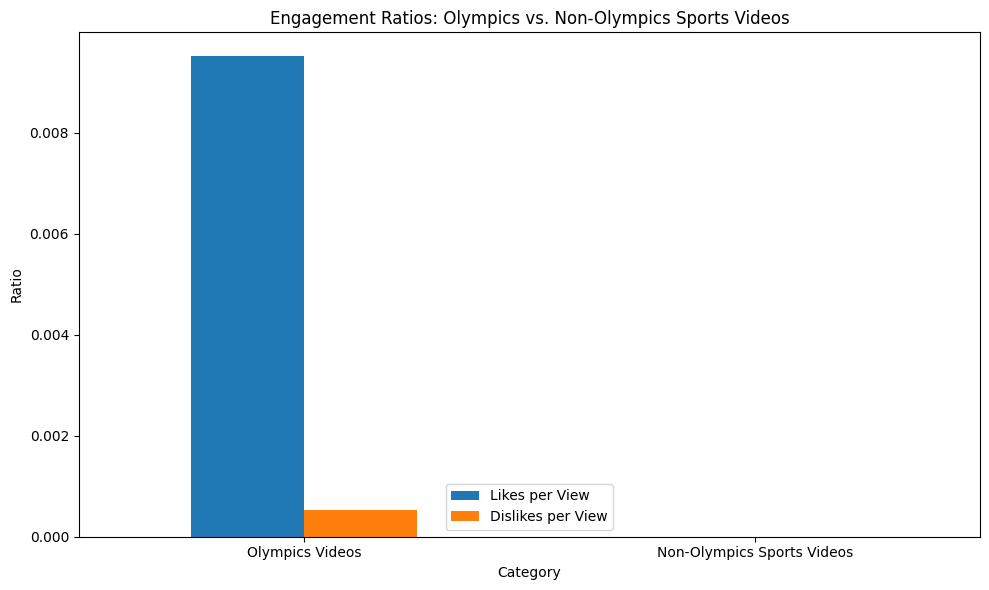

In [82]:
# Calculate engagement ratios
olympics_videos['likes_per_view'] = olympics_videos['like_count'] / olympics_videos['view_count']
olympics_videos['dislikes_per_view'] = olympics_videos['dislike_count'] / olympics_videos['view_count']

non_olympics_videos['likes_per_view'] = non_olympics_videos['like_count'] / non_olympics_videos['view_count']
non_olympics_videos['dislikes_per_view'] = non_olympics_videos['dislike_count'] / non_olympics_videos['view_count']
print(olympics_videos[['likes_per_view', 'dislikes_per_view']].head())
print(non_olympics_videos[['likes_per_view', 'dislikes_per_view']].head())


# Calculate average ratios
avg_ratios = pd.DataFrame({
    'Category': ['Olympics Videos', 'Non-Olympics Sports Videos'],
    'Likes per View': [
        olympics_videos['likes_per_view'].mean(),
        non_olympics_videos['likes_per_view'].mean()
    ],
    'Dislikes per View': [
        olympics_videos['dislikes_per_view'].mean(),
        non_olympics_videos['dislikes_per_view'].mean()
    ]
})

print(avg_ratios)

# Visualization
avg_ratios.set_index('Category').plot(kind='bar', figsize=(10,6))
plt.title('Engagement Ratios: Olympics vs. Non-Olympics Sports Videos')
plt.ylabel('Ratio')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## Analysing a specific event

In [95]:


# Ensure you're working with a copy to avoid SettingWithCopyWarning
london_2012_videos = olympics_videos[
    (olympics_videos['title_lower'].str.contains('london 2012')) |
    (olympics_videos['tags_lower'].str.contains('london 2012'))
].copy()

# Verify the subset
print(f"Total London 2012 Olympics Videos: {len(london_2012_videos)}")

london_2012_videos = olympics_videos[
    (olympics_videos['title_lower'].str.contains('london 2012')) |
    (olympics_videos['tags_lower'].str.contains('london 2012'))
].copy()

# Verify the subset
print(f"Total London 2012 Olympics Videos: {len(london_2012_videos)}")

# Define additional keywords related to London 2012
london_keywords = ['london olympics', '2012 olympic games', 'london 2012', 'olympics london 2012']

# Function to check if any London keyword is present
def is_london_video(title, tags):
    if pd.isnull(title) and pd.isnull(tags):
        return False
    combined_text = ''
    if pd.notnull(title):
        combined_text += title.lower()
    if pd.notnull(tags):
        combined_text += ' ' + tags.lower()
    return any(keyword in combined_text for keyword in london_keywords)

# Apply the function to filter videos
london_2012_videos = olympics_videos[olympics_videos.apply(
    lambda row: is_london_video(row['title'], row['tags']), axis=1
)].copy()

# Verify the subset
print(f"Total London 2012 Olympics Videos after expanding keywords: {len(london_2012_videos)}")

# Define the start and end dates for the analysis window
event_start = datetime(2012, 7, 27)
event_end = datetime(2012, 8, 12)

window_start = event_start - timedelta(days=30)
window_end = event_end + timedelta(days=30)

# Filter videos within the window
london_window_videos = london_2012_videos[
    (london_2012_videos['upload_date'] >= window_start) &
    (london_2012_videos['upload_date'] <= window_end)
].copy()

print(f"Total London 2012 Videos in Analysis Window: {len(london_window_videos)}")
# Aggregate daily upload counts
daily_uploads = london_window_videos.groupby(london_window_videos['upload_date'].dt.date).size().reset_index(name='upload_count')

# Display the first few rows
print(daily_uploads.head())


Total London 2012 Olympics Videos: 14184
Total London 2012 Olympics Videos: 14184
Total London 2012 Olympics Videos after expanding keywords: 14611
Total London 2012 Videos in Analysis Window: 3556
  upload_date  upload_count
0  2012-06-27            30
1  2012-06-28            15
2  2012-06-29             6
3  2012-06-30             2
4  2012-07-01             7


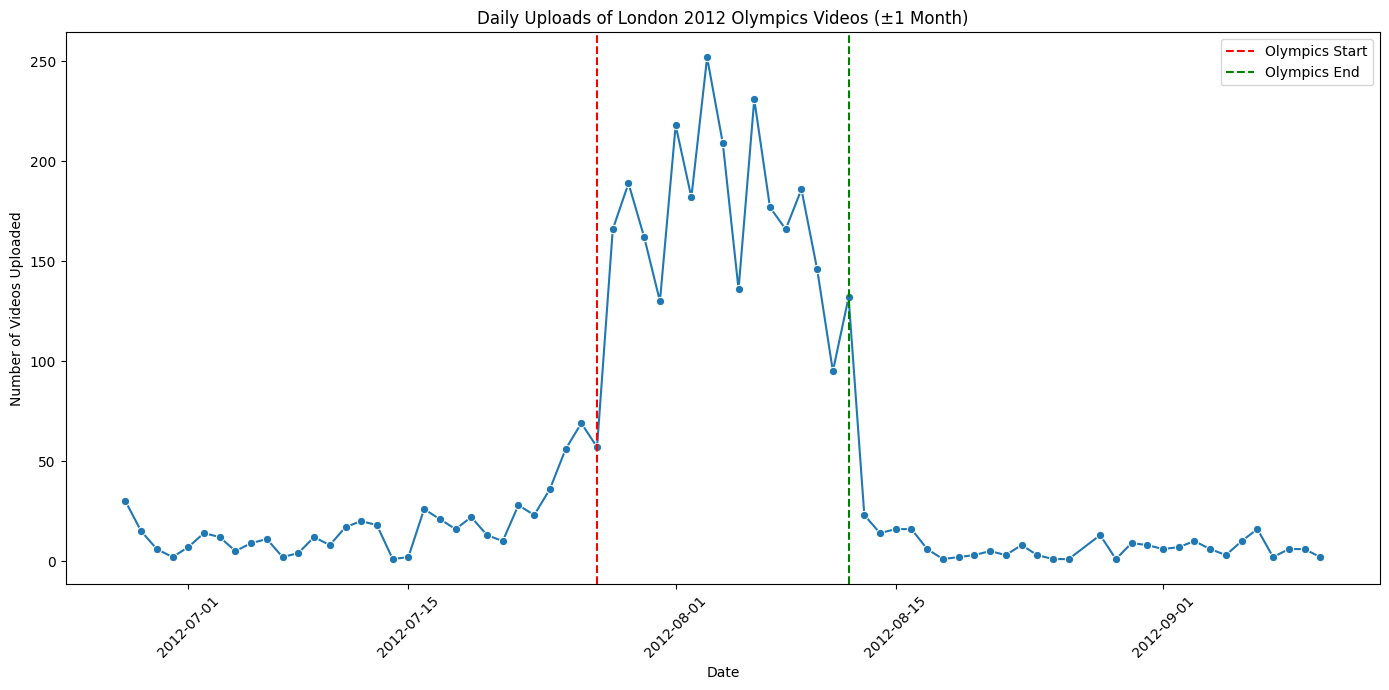

In [93]:
import seaborn as sns
plt.figure(figsize=(14,7))
sns.lineplot(data=daily_uploads, x='upload_date', y='upload_count', marker='o')
plt.axvline(event_start, color='red', linestyle='--', label='Olympics Start')
plt.axvline(event_end, color='green', linestyle='--', label='Olympics End')
plt.title('Daily Uploads of London 2012 Olympics Videos (±1 Month)')
plt.xlabel('Date')
plt.ylabel('Number of Videos Uploaded')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Average Engagement Metrics for London 2012 Olympics Videos:
view_count       246621.389201
like_count          573.867548
dislike_count        36.122328
dtype: float64
Average Engagement Metrics for Non-Olympics Sports Videos (Same Window):
view_count       39078.099442
like_count         202.429668
dislike_count       12.053802
dtype: float64
          Metric  London 2012 Olympics Videos  Non-Olympics Sports Videos
0     View Count                246621.389201                39078.099442
1     Like Count                   573.867548                  202.429668
2  Dislike Count                    36.122328                   12.053802


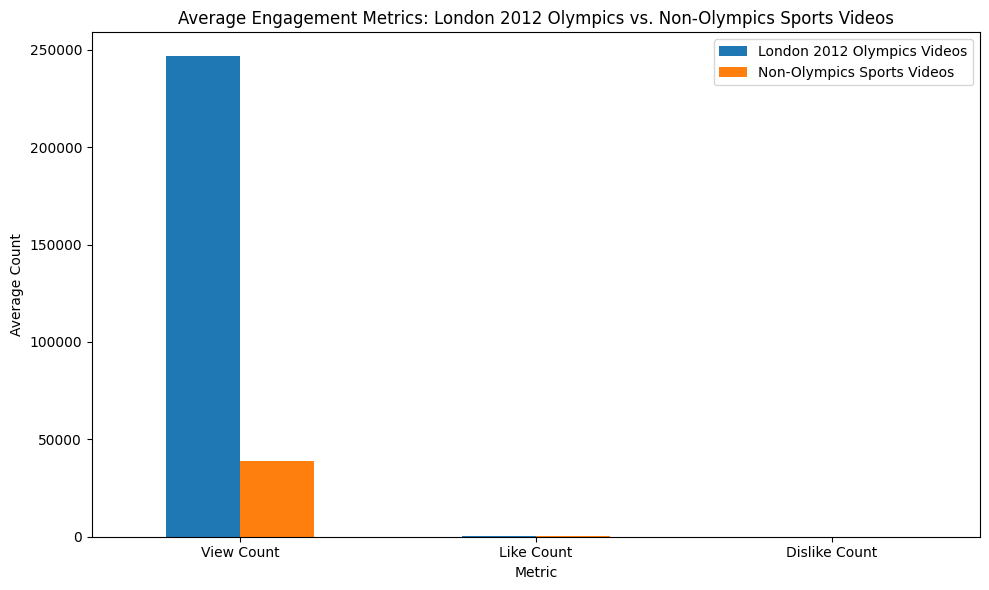

In [94]:
# Convert relevant columns to numeric types
numeric_columns = ['view_count', 'like_count', 'dislike_count']
for col in numeric_columns:
    london_window_videos[col] = pd.to_numeric(london_window_videos[col], errors='coerce')

# Handle missing values by filling with zero or appropriate imputation
london_window_videos[numeric_columns] = london_window_videos[numeric_columns].fillna(0)
avg_engagement_london = london_window_videos[numeric_columns].mean()
print("Average Engagement Metrics for London 2012 Olympics Videos:")
print(avg_engagement_london)


# Filter non-Olympics sports videos within the same window
non_olympics_window_videos = df[
    (~df['is_olympics']) &
    (df['upload_date'] >= window_start) &
    (df['upload_date'] <= window_end)
].copy()

# Convert to numeric and handle missing values
for col in numeric_columns:
    non_olympics_window_videos[col] = pd.to_numeric(non_olympics_window_videos[col], errors='coerce')
non_olympics_window_videos[numeric_columns] = non_olympics_window_videos[numeric_columns].fillna(0)

# Calculate average engagement metrics
avg_engagement_non_olympics = non_olympics_window_videos[numeric_columns].mean()

print("Average Engagement Metrics for Non-Olympics Sports Videos (Same Window):")
print(avg_engagement_non_olympics)

comparison_df = pd.DataFrame({
    'Metric': ['View Count', 'Like Count', 'Dislike Count'],
    'London 2012 Olympics Videos': [
        avg_engagement_london['view_count'],
        avg_engagement_london['like_count'],
        avg_engagement_london['dislike_count']
        ],
    'Non-Olympics Sports Videos': [
        avg_engagement_non_olympics['view_count'],
        avg_engagement_non_olympics['like_count'],
        avg_engagement_non_olympics['dislike_count']
    ]
})

print(comparison_df)

# Set the 'Metric' as the index for plotting
comparison_df.set_index('Metric', inplace=True)

# Plot the comparison
comparison_df.plot(kind='bar', figsize=(10,6))
plt.title('Average Engagement Metrics: London 2012 Olympics vs. Non-Olympics Sports Videos')
plt.ylabel('Average Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


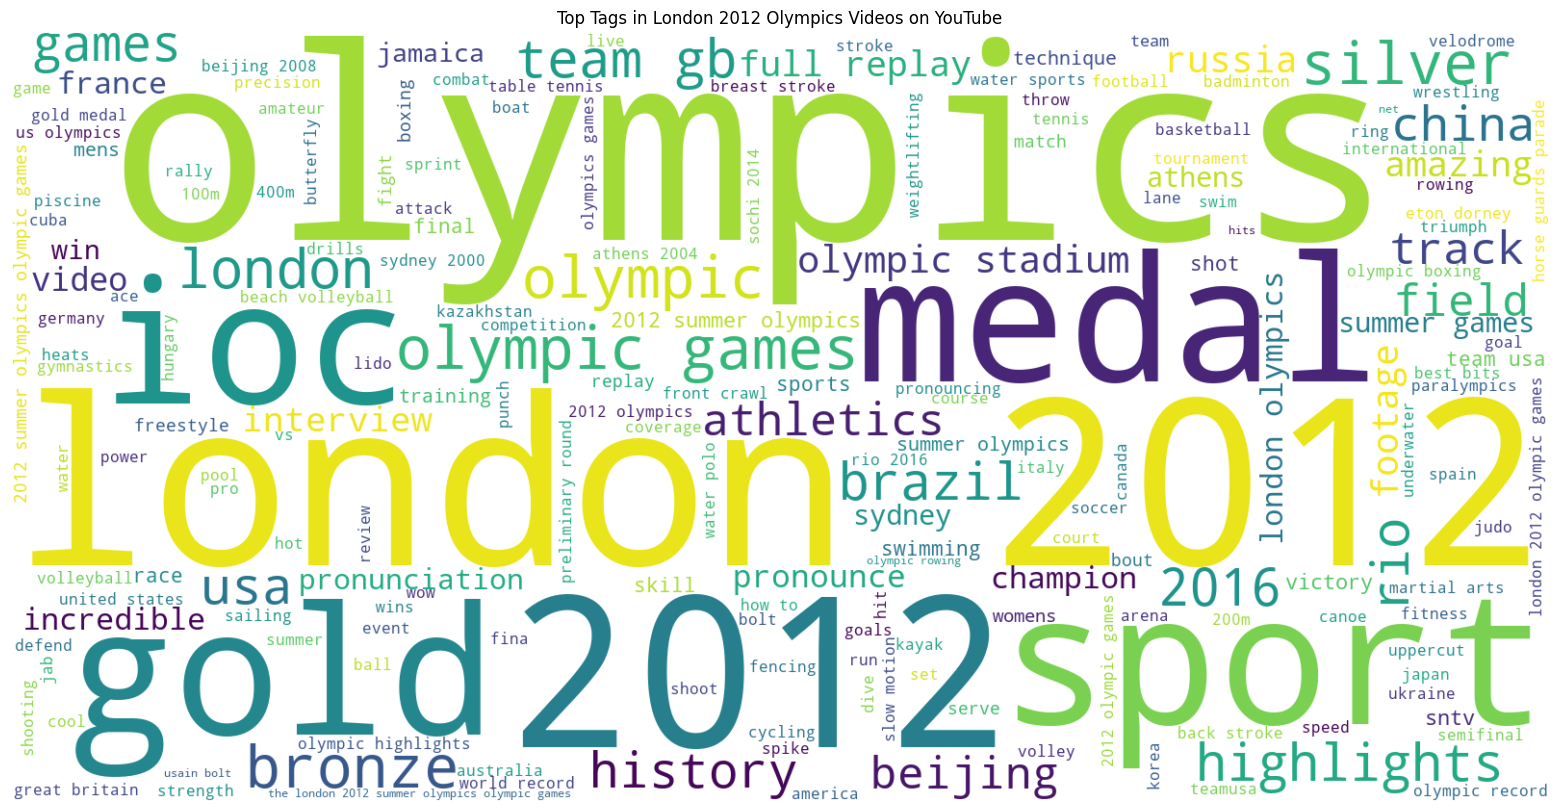

In [96]:
from collections import Counter
from wordcloud import WordCloud
import re

# Preprocess tags: split by commas, remove non-alphanumeric characters
def preprocess_tags(tags):
    if pd.isnull(tags):
        return []
    tags = tags.lower().split(',')
    tags = [re.sub(r'[^a-z0-9\s]', '', tag).strip() for tag in tags]
    tags = [tag for tag in tags if tag]
    return tags

# Apply preprocessing
london_window_videos['processed_tags'] = london_window_videos['tags'].apply(preprocess_tags)

# Flatten the list of tags
all_tags = [tag for sublist in london_window_videos['processed_tags'] for tag in sublist]

# Count tag frequencies
tag_counts = Counter(all_tags)

# Generate Word Cloud
wordcloud = WordCloud(width=1600, height=800, background_color='white').generate_from_frequencies(tag_counts)

plt.figure(figsize=(20,10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Top Tags in London 2012 Olympics Videos on YouTube')
plt.show()


sentiment_category
Neutral     2169
Positive    1124
Negative     263
Name: count, dtype: int64


/var/folders/77/5ydnmbx94b19w3vljgff8zlm0000gn/T/ipykernel_84638/2896172852.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment_category', data=london_window_videos, palette='coolwarm')


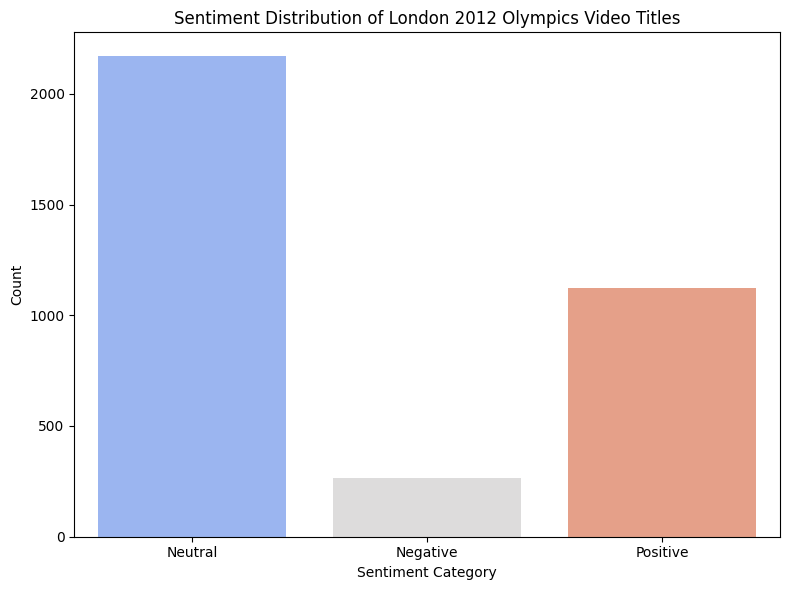

In [97]:
# Function to compute sentiment polarity
def get_sentiment(text):
    if pd.isnull(text):
        return 0
    return TextBlob(text).sentiment.polarity  # Range: -1 (negative) to 1 (positive)

# Apply sentiment analysis on video titles
london_window_videos['sentiment'] = london_window_videos['title'].apply(get_sentiment)

# Categorize sentiments
london_window_videos['sentiment_category'] = london_window_videos['sentiment'].apply(
    lambda x: 'Positive' if x > 0.05 else ('Negative' if x < -0.05 else 'Neutral')
)

# Display sentiment distribution
print(london_window_videos['sentiment_category'].value_counts())

# Visualization
plt.figure(figsize=(8,6))
sns.countplot(x='sentiment_category', data=london_window_videos, palette='coolwarm')
plt.title('Sentiment Distribution of London 2012 Olympics Video Titles')
plt.xlabel('Sentiment Category')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


In [100]:
pip install vaderSentiment


[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


vader_sentiment_category
Neutral     1856
Positive    1592
Negative     108
Name: count, dtype: int64


/var/folders/77/5ydnmbx94b19w3vljgff8zlm0000gn/T/ipykernel_84638/2109586064.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='vader_sentiment_category', data=london_window_videos, palette='magma')


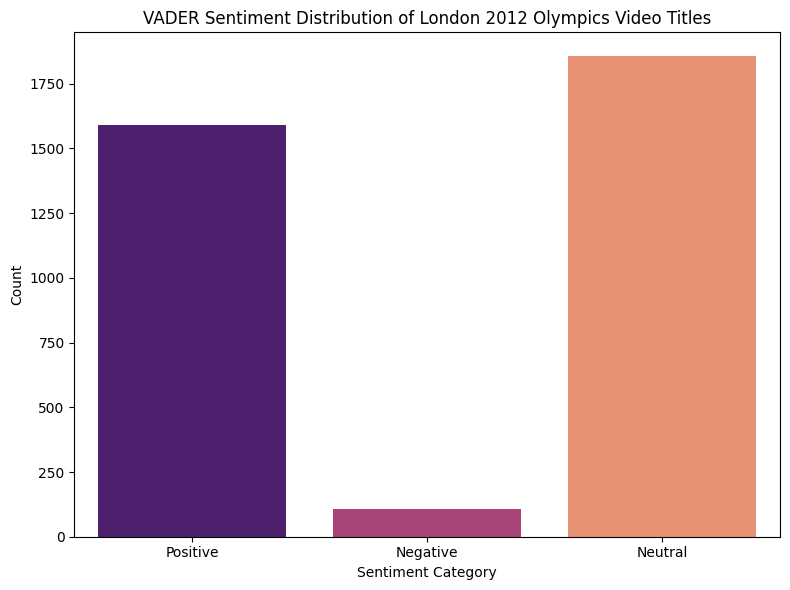

In [101]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Initialize VADER sentiment analyzer
analyzer = SentimentIntensityAnalyzer()

# Function to compute VADER sentiment
def vader_sentiment(text):
    if pd.isnull(text):
        return 0
    return analyzer.polarity_scores(text)['compound']

# Apply VADER sentiment analysis
london_window_videos['vader_sentiment'] = london_window_videos['title'].apply(vader_sentiment)

# Categorize sentiments
london_window_videos['vader_sentiment_category'] = london_window_videos['vader_sentiment'].apply(
    lambda x: 'Positive' if x >= 0.05 else ('Negative' if x <= -0.05 else 'Neutral')
)

# Display sentiment distribution
print(london_window_videos['vader_sentiment_category'].value_counts())

# Visualization
plt.figure(figsize=(8,6))
sns.countplot(x='vader_sentiment_category', data=london_window_videos, palette='magma')
plt.title('VADER Sentiment Distribution of London 2012 Olympics Video Titles')
plt.xlabel('Sentiment Category')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


In [102]:
# Identify top 10 channels with the most London 2012 Olympics videos
top_channels = london_window_videos['channel_id'].value_counts().head(10).index.tolist()

# Filter videos from these top channels
top_channels_videos = london_window_videos[london_window_videos['channel_id'].isin(top_channels)].copy()

print("Top 10 Channels with Most London 2012 Olympics Videos:")
print(top_channels_videos['channel_id'].value_counts())


Top 10 Channels with Most London 2012 Olympics Videos:
channel_id
UCTl3QQTvqHFjurroKxexy2Q    1727
UCU-HGStP8v-WXtqXlV2bUHQ     557
UC5yB3mDwRyLNeRvfCSdKMeg     266
UCPGpDwKpKj9vcoFAOxSbr7A     210
UCK7tptUDHh-RYDsdxO1-5QQ      57
UCZHfmiIPaWQSsKsEUg-_xpA      55
UChy5dW4S_x8XOnoXyeLQLXQ      51
UCtb3UIeUwTIjO1qgCqcAUww      37
UCgnNMWzQxX4yxYHk6-uK-HA      31
UCHpw8xwDNhU9gdohEcJu4aA      26
Name: count, dtype: int64


In [104]:
# Calculate average engagement metrics for top channels
channel_engagement = top_channels_videos.groupby('channel_id')[['view_count', 'like_count', 'dislike_count']].mean().reset_index()

print("Average Engagement Metrics for Top Channels:")
print(channel_engagement)


Average Engagement Metrics for Top Channels:
                 channel_id     view_count   like_count  dislike_count
0  UC5yB3mDwRyLNeRvfCSdKMeg    3593.661654     6.769811       1.935849
1  UCHpw8xwDNhU9gdohEcJu4aA   53878.384615   139.807692      17.307692
2  UCK7tptUDHh-RYDsdxO1-5QQ  131755.333333   408.438596      77.087719
3  UCPGpDwKpKj9vcoFAOxSbr7A   90369.214286   374.952381      12.738095
4  UCTl3QQTvqHFjurroKxexy2Q  481453.004053  1574.247257      92.061603
5  UCU-HGStP8v-WXtqXlV2bUHQ    1360.267504     2.533214       6.709156
6  UCZHfmiIPaWQSsKsEUg-_xpA    8357.727273     5.500000      18.000000
7  UCgnNMWzQxX4yxYHk6-uK-HA    1482.322581     5.903226       0.258065
8  UChy5dW4S_x8XOnoXyeLQLXQ    1055.411765     1.803922       0.039216
9  UCtb3UIeUwTIjO1qgCqcAUww    6473.189189    24.729730       3.729730


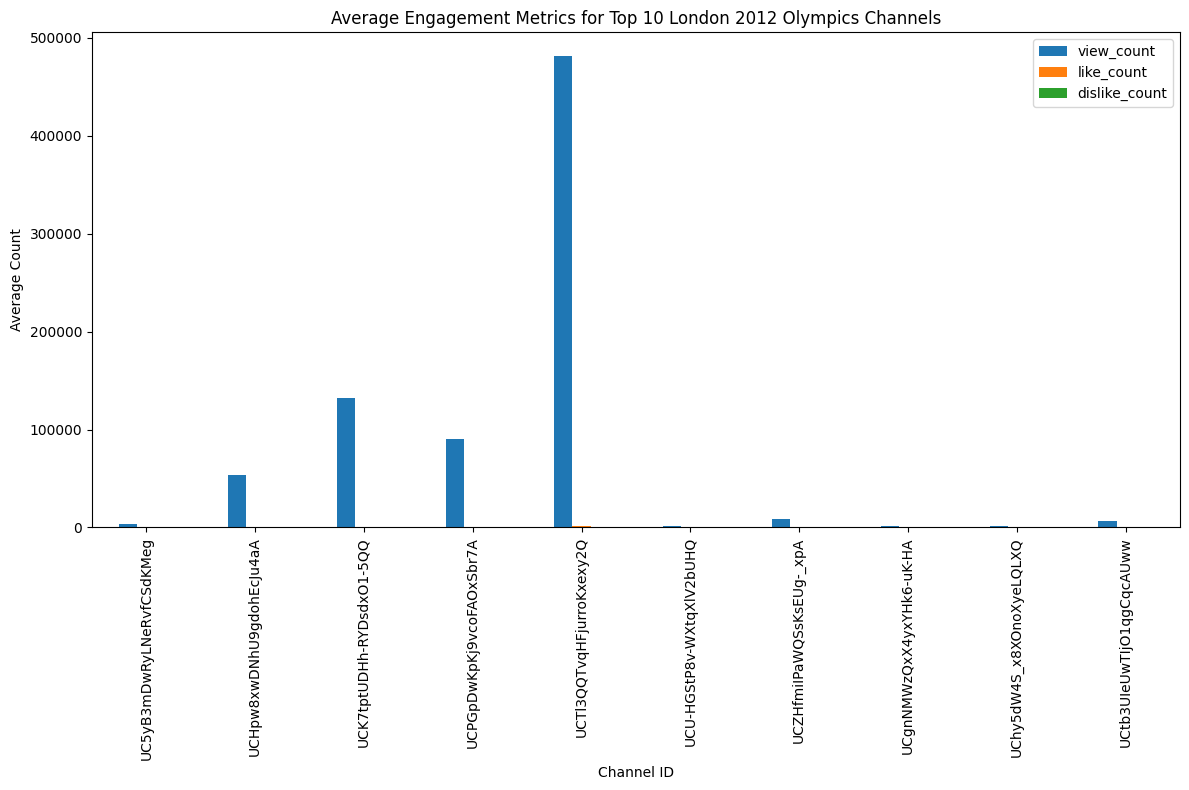

In [105]:
# Plot engagement metrics for top channels
channel_engagement.set_index('channel_id').plot(kind='bar', figsize=(12,8))
plt.title('Average Engagement Metrics for Top 10 London 2012 Olympics Channels')
plt.ylabel('Average Count')
plt.xlabel('Channel ID')
plt.tight_layout()
plt.show()


In [107]:
from scipy.stats import ttest_ind

# Define metrics to test
metrics = ['view_count', 'like_count', 'dislike_count']

# Initialize a dictionary to store results
t_test_results = {}

for metric in metrics:
    t_stat, p_val = ttest_ind(
        london_window_videos[metric].dropna(),
        non_olympics_window_videos[metric].dropna(),
        equal_var=False  # Welch's t-test
    )
    t_test_results[metric] = {'t-statistic': t_stat, 'p-value': p_val}

# Convert results to DataFrame for better visualization
t_test_df = pd.DataFrame(t_test_results).T
print("T-Test Results Comparing London 2012 Olympics Videos to Non-Olympics Sports Videos:")
print(t_test_df)


T-Test Results Comparing London 2012 Olympics Videos to Non-Olympics Sports Videos:
               t-statistic       p-value
view_count        8.840273  1.461559e-18
like_count        2.757895  5.852805e-03
dislike_count     5.876150  4.640140e-09
